# Photonic QGAN with `PhotonicGenerator`

This notebook demonstrates a compact Adam-trained photonic QGAN workflow using MerLin's `PhotonicGenerator`. It follows the structure of the photonic QGAN model at documentation scale: repeated quantum generator heads produce image patches, `ImageAdapter` assembles them into images, and a classical discriminator trains against Optdigits samples.

The run below reproduces the results obtained in the [reproduction in MerLin](https://github.com/merlinquantum/reproduced_papers/tree/main/papers/photonic_QGAN) of the original [photonic QGAN paper](https://opg.optica.org/opticaq/fulltext.cfm?uri=opticaq-2-6-458) by Sedrakyan and Salavrakos.

## Introduction to Classical Generative Adversarial Networks (GAN)

Describe gan, generator + discriminator, training steps....


Lets now define the specific training steps of a GAN.

1. For a number of ``iterations``:
    1. For a number of discriminator iterations ``d_steps``:
        1. Train the discriminator parameters with the batches fake and real images. The labels of the real values are ``real_labels`` and the fake images' labels are ``fake_labels``. Here, after the hyper parameter optimization done in the reproduction, we will choose ``real_labels=0.9`` and ``fake_labels=0.0``.


![Photonic QGAN overview](../../_static/reproduced_papers/photonicQGAN.png)

In [1]:
from __future__ import annotations

import copy
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import torch
from sklearn.datasets import load_digits
from torch import nn

import merlin as ML

## Configuration

We will use the same experiment setup as the setup d of the reproduction. We will also use all of the optimized hyperparameter identified in the study of the photonic QGAN's MerLin reproduction.

The demo uses four patch heads, two latent features, an 8 by 8 digit target (MNIST 0th digit), and one discriminator update followed by three generator updates.

In [2]:
seed = 0
digit = 0
training_iterations = 1400
batch_size = 4
image_size = 8
latent_dim = 2
generator_heads = 4

input_state = (0, 1, 0, 1, 0)

lr_d = 0.0002
lr_g = 0.004
adam_betas = (0.5, 0.99)
d_steps = 1
g_steps = 3

random.seed(seed)
np.random.seed(seed)
_ = torch.manual_seed(seed)

## Load Optdigits Samples

The notebook uses `sklearn.datasets.load_digits`, so it can run without a separate data checkout. Pixel values are normalized to `[0, 1]`.

In [3]:
digits = load_digits()
mask = digits.target == digit
real_images = torch.tensor(digits.images[mask], dtype=torch.float32).unsqueeze(1) / 16.0
real_vectors = real_images.reshape(real_images.shape[0], -1)

sample_generator = torch.Generator().manual_seed(seed + 17)
batch_indices = torch.randint(
    real_vectors.shape[0],
    (training_iterations, batch_size),
    generator=sample_generator,
)
real_batches = [real_vectors[indices] for indices in batch_indices]
real_preview = real_images[batch_indices[0]]

print(f"digit samples: {real_vectors.shape[0]}")
print(f"training batches: {len(real_batches)}")

digit samples: 178
training batches: 1400


## Build the MerLin Photonic Generator

In order to get similar results as the one identified in the [photonic QGAN paper](https://opg.optica.org/opticaq/fulltext.cfm?uri=opticaq-2-6-458) and in the [photonic QGAN reproduction with MerLin](https://github.com/merlinquantum/reproduced_papers/tree/main/papers/photonic_QGAN), we will use the same circuit unitaries as presented in the paper. Below is the photonic circuit implementation.

![Photonic QGAN circuit](../../_static/reproduced_papers/fig3_pqgan.png)

In [4]:
def var_circuit(n_modes:int,param_start_index:int=0)->pcvl.Circuit:
    trainable_params=[pcvl.Parameter(f"phi{i+param_start_index}") for i in range((2*n_modes)-1)]
    circ=pcvl.Circuit(m=n_modes)
    for i in range(n_modes):
        circ.add([i],component=pcvl.PS(trainable_params[i]))
    for i,j in enumerate(range(0,n_modes-1,2)):
        circ.add([j,j+1],component=pcvl.BS(trainable_params[i+n_modes]))
    for i,j in enumerate(range(1,n_modes-1,2)):
        circ.add([j,j+1],component=pcvl.BS(trainable_params[i+n_modes+(n_modes//2)]))
    
    return circ

def encoding_circuit(n_modes:int,mode_to_target:int,param_index:int=0)->pcvl.Circuit:
    encoding_param=pcvl.Parameter(f"theta{param_index}")
    circ=pcvl.Circuit(m=n_modes)
    circ.add([mode_to_target],component=pcvl.PS(encoding_param))

    return circ

We will then use those base bricks to create the subgenerator pattern d in the paper.

![Photonic QGAN circuit](../../_static/reproduced_papers/fig4d_pqgan.png)

We will create a ``QuantumLayer`` out of these Perceval circuits created earlier.

In [ ]:
def create_subgenerator(use_pnr_detectors:bool=False) -> ML.QuantumLayer:
    #Define the complete Perceval Circuit
    m=len(input_state)
    circuit=pcvl.Circuit(m=m)
    circuit.add(port_range=[i for i in range(m)],component=var_circuit(n_modes=m,param_start_index=0))
    circuit.add(port_range=[i for i in range(m)],component=encoding_circuit(n_modes=m,mode_to_target=1,param_index=0))
    circuit.add(port_range=[i for i in range(m)],component=var_circuit(n_modes=m,param_start_index=(2*m)-1))
    circuit.add(port_range=[i for i in range(m)],component=encoding_circuit(n_modes=m,mode_to_target=3,param_index=1))
    circuit.add(port_range=[i for i in range(m)],component=var_circuit(n_modes=m,param_start_index=(4*m)-2))

    #Define the Perceval experiment
    exp=pcvl.Experiment(circuit)
    
    #If the user does not want PNR detectors, remove them.
    if not use_pnr_detectors:
        for i in range(m):
            exp.detectors[i]=pcvl.Detector.threshold()

    #Create the corresponding QuantumLayer
    return ML.QuantumLayer(
        input_size=latent_dim,
        experiment=exp,
        input_state=input_state,
        trainable_parameters=["phi"],
        input_parameters=["theta"],
        measurement_strategy=ML.MeasurementStrategy.probs(
            computation_space=ML.ComputationSpace.FOCK,
            occupancy_readout=True,
        ),
    )

heads: 4
trainable parameters: 108
per-head output widths: [15, 15, 15, 15]
image batch shape: (4, 1, 8, 8)


Lets now define the ``PhotonicGenerator`` with this ``QuantumLayer``.

We will use `count=4` that creates four independent heads with the same circuit structure. Each head returns Fock-space probabilities with binary occupancy readout, then the image adapter maps each head to one patch of the generated image. 

This is the same idea as presented in the paper to use multiple photonic circuit as patches to create one image.

In [ ]:
generator = ML.PhotonicGenerator(
    layers=create_subgenerator(use_pnr_detectors=False),
    count=generator_heads,
    output_adapter=ML.ImageAdapter(
        shape=(1, image_size, image_size),
        headwise=True,
        normalize_patches=True,
    ),
)

fixed_noise = torch.normal(0.0, 2 * math.pi, (batch_size, latent_dim))
with torch.no_grad():
    generated_before = generator(fixed_noise).detach()

measurements = generator.measure(fixed_noise)
print(f"heads: {len(generator)}")
print(f"trainable parameters: {sum(p.numel() for p in generator.parameters())}")
print(f"per-head output widths: {[output.shape[1] for output in measurements.outputs]}")
print(f"image batch shape: {tuple(generated_before.shape)}")

## Defining the Classical Discriminator

The classical discriminator is just a regular ``pytorch`` module. We will use the same one as in the paper reproduction.

In [ ]:
discriminator = nn.Sequential(
    nn.Linear(image_size * image_size, 32),
    nn.LeakyReLU(0.2),
    nn.Linear(32, 16),
    nn.LeakyReLU(0.2),
    nn.Linear(16, 1),
)

## Train with Adam

In order to train the Photonic QGAN, we need to follow the specific training structure of the classical GAN. We will use the ADAM optimizer as it is the most fitted for MerLin use even though the original paper used SPSA. A study on the optimization of ADAM's parameter is also available in the MerLin reproduction. It will be presented later. First, we need to define the performance metrics.

### Defining the Metrics

We will use different metrics to analyze the training and performance of the photonic QGAN. We will define a batch similarity which determines how close the fake generated images of the current batch are close to the real images. This metric is basically the average of the structural similarity (ssim) between all pairs of fake and real images on the batch.

In [ ]:
def global_ssim(x: np.ndarray, y: np.ndarray) -> float:
    c1 = 0.01**2
    c2 = 0.03**2
    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    mu_x = float(x.mean())
    mu_y = float(y.mean())
    var_x = float(((x - mu_x) ** 2).mean())
    var_y = float(((y - mu_y) ** 2).mean())
    cov_xy = float(((x - mu_x) * (y - mu_y)).mean())
    numerator = (2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)
    denominator = (mu_x**2 + mu_y**2 + c1) * (var_x + var_y + c2)
    return numerator / denominator


def batch_similarity(real: torch.Tensor, fake: torch.Tensor) -> float:
    real_batch = real.detach().cpu().numpy().reshape(batch_size, image_size, image_size)
    fake_batch = fake.detach().cpu().numpy().reshape(batch_size, image_size, image_size)
    total = 0.0
    for real_image in real_batch:
        for fake_image in fake_batch:
            total += global_ssim(
                np.clip(real_image, 0.0, 1.0),
                np.clip(fake_image, 0.0, 1.0),
            )
    return total / (batch_size * batch_size)

### Training the Photonic QGAN

We will use the same training steps as the classical GAN to train our photonic QGAN. Since the generator and discriminator are ordinary PyTorch modules. `loss.backward()` populates gradients for the MerLin quantum layers, and the user-selected Adam optimizers own the parameter updates

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=adam_betas)
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=adam_betas)

noise_generator = torch.Generator().manual_seed(seed + 31)
d_losses: list[float] = []
g_losses: list[float] = []
similarity_scores: list[float] = []
best_similarity = float("-inf")
best_state = copy.deepcopy(generator.state_dict())
best_iteration = 0


for iteration, real_data in enumerate(real_batches, start=1):
    real_labels = torch.full((batch_size,), 0.9)
    fake_labels = torch.zeros(batch_size)
    generator_labels = torch.full((batch_size,), 0.9)

    # Discriminator training
    d_step_losses = []
    for _ in range(d_steps):
        noise_d = torch.normal(
            0.0,
            2 * math.pi,
            (batch_size, latent_dim),
            generator=noise_generator,
        )
        fake_for_d = generator(noise_d).reshape(batch_size, -1).detach()

        optimizer_d.zero_grad()
        d_loss = criterion(discriminator(real_data).view(-1), real_labels)
        d_loss = d_loss + criterion(discriminator(fake_for_d).view(-1), fake_labels)
        d_loss.backward()
        optimizer_d.step()
        d_step_losses.append(float(d_loss.detach()))


    # Freezing the discriminator for the generator training
    for parameter in discriminator.parameters():
        parameter.requires_grad_(False)
    
    # Generator training
    g_step_losses = []
    fake_for_metrics = None
    for _ in range(g_steps):
        noise_g = torch.normal(
            0.0,
            2 * math.pi,
            (batch_size, latent_dim),
            generator=noise_generator,
        )
        optimizer_g.zero_grad()
        fake_for_g = generator(noise_g).reshape(batch_size, -1)
        g_loss = criterion(discriminator(fake_for_g).view(-1), generator_labels)
        g_loss.backward()
        optimizer_g.step()
        g_step_losses.append(float(g_loss.detach()))
        fake_for_metrics = fake_for_g


    # Defreezing the discriminator for the discriminator training
    for parameter in discriminator.parameters():
        parameter.requires_grad_(True)

    if fake_for_metrics is None:
        raise RuntimeError("Generator update did not produce samples.")
    

    # Get the performance of the iteration
    similarity = batch_similarity(real_data, fake_for_metrics)
    if similarity > best_similarity:
        best_similarity = similarity
        best_iteration = iteration
        best_state = copy.deepcopy(generator.state_dict())

    d_losses.append(float(np.mean(d_step_losses)))
    g_losses.append(float(np.mean(g_step_losses)))
    similarity_scores.append(similarity)


# Best result of the training
generator.load_state_dict(best_state)
with torch.no_grad():
    generated_best = generator(fixed_noise).detach()

has_generator_gradient = any(
    parameter.grad is not None and parameter.grad.abs().sum() > 0
    for parameter in generator.parameters()
)

print(f"training iterations: {training_iterations}")
print(f"best iteration: {best_iteration}")
print(f"best batch similarity: {best_similarity:.3f}")
print(f"generator gradients populated: {has_generator_gradient}")

training iterations: 1400
best iteration: 500
best batch similarity: 0.712
generator gradients populated: True


## Results

The first row shows real digit-0 samples. The second row shows the generates digits before training. The third row shows the best checkpoint selected during the Adam run.

We then plot the losses and batch similarity scores per epoch.

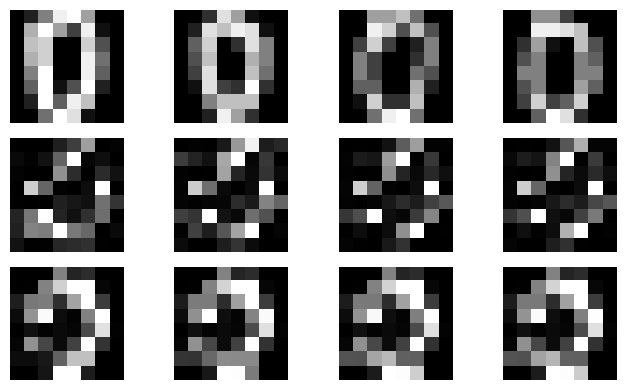

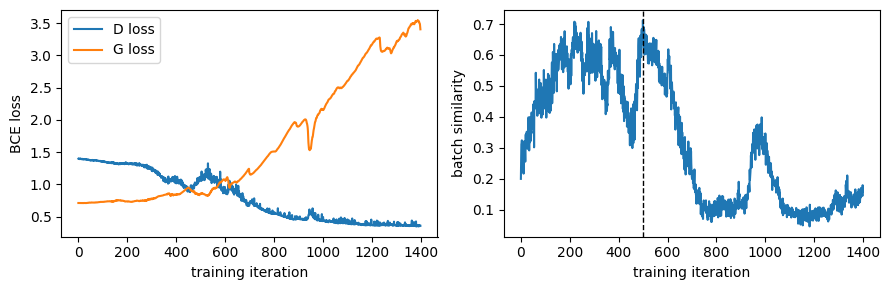

In [7]:
def show_grid(images: torch.Tensor, title: str, axes: np.ndarray) -> None:
    flat_axes = axes.reshape(-1)
    for axis, image in zip(flat_axes, images, strict=False):
        axis.imshow(image.squeeze().cpu(), cmap="gray", vmin=0.0, vmax=1.0)
        axis.axis("off")
    for axis in flat_axes[len(images):]:
        axis.axis("off")
    axes[0].set_ylabel(title, rotation=0, labelpad=35, va="center")


fig, axes = plt.subplots(3, batch_size, figsize=(7, 4))
show_grid(real_preview, "real", axes[0])
show_grid(generated_before, "before", axes[1])
show_grid(generated_best, "best", axes[2])
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(d_losses, label="D loss")
axes[0].plot(g_losses, label="G loss")
axes[0].set_xlabel("training iteration")
axes[0].set_ylabel("BCE loss")
axes[0].legend()

axes[1].plot(similarity_scores)
axes[1].axvline(best_iteration - 1, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("training iteration")
axes[1].set_ylabel("batch similarity")
fig.tight_layout()
plt.show()

We observe the expected tendencies of the losses identified in the original paper. The generator loss increases as the discriminator ones decreases.

## What this demonstrates

This notebook exercises the public MerLin path needed by the photonic QGAN model: repeated independent generator heads via `PhotonicGenerator(..., count=...)`, Fock-space occupancy readout, headwise image adaptation, a classical discriminator, and standard PyTorch Adam updates. The example is intentionally small; paper-scale experiments should use longer runs and checkpoint selection.